In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from pygris import tracts
from scipy.stats import chi2_contingency

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, roc_auc_score
from shapely.geometry import Point

In [2]:
#setting pandas columns so I can see all of them
pd.set_option('display.max_columns', None)

#reading in data
cejst = pd.read_csv("CEJST_2.0-communities.csv", low_memory = False)
atlas = pd.read_csv('im3_open_source_data_center_atlas_v2026.02.09.csv')
fractracker = pd.read_csv("U.S. Data Centers - FracTracker.csv")

In [3]:
#cleaning fractracker

#setting numeric columns; removing commas
#can check if this worked with "fractracker.dtypes"
numeric_columns = ["MW (high)", "MW (low)", "Number of generators", "Number of buildings"]
for column in numeric_columns:
    fractracker[column] = pd.to_numeric(fractracker[column].str.replace(',', ''), errors='coerce')


In [4]:
#cleaning cejst

cejst = cejst.rename(columns={'Census tract 2010 ID':'GEOID'})
cejst = cejst.rename(columns={"State/Territory":"State"})

In [5]:
# Read the shapefile
census_tracts = gpd.read_file("tl_2025_39_tract.zip")

#this is to remove the lakes
census_tracts = census_tracts[census_tracts['ALAND'] > 1_000_000]

#census_tracts.crs

In [6]:
#combining cejst and fractracker into a dataset that I can use for linear regression
#the following code is from Claude


# Import necessary libraries
import geopandas as gpd
import pandas as pd
from pygris import tracts

# --- STEP 1: Prepare fractracker data ---
selected_statuses = ["Operating", "Expanding", "Proposed"]
fractracker_prop = fractracker[fractracker['Status'].isin(selected_statuses)].copy()
#fractracker_prop = fractracker[fractracker.Status == "Operating", "Expanding", "Proposed"].copy()

# --- STEP 2: Download all US census tracts ---
states = [
    '01', '02', '04', '05', '06', '08', '09', '10', '11', '12', '13', '15', '16',
    '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29',
    '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42',
    '44', '45', '46', '47', '48', '49', '50', '51', '53', '54', '55', '56', '72'
]

all_tracts = []
for state in states:
    try:
        state_tracts = tracts(state=state, year=2021, cb=True)
        all_tracts.append(state_tracts)
    except Exception as e:
        print(f"Failed for {state}: {e}")

tract_geometries = gpd.GeoDataFrame(pd.concat(all_tracts, ignore_index=True))

# --- STEP 3: Prepare CEJST data with geometry ---
# Fix GEOID data types to match
cejst['GEOID'] = cejst['GEOID'].astype(str).str.zfill(11)  # Ensure 11 digits with leading zeros
tract_geometries['GEOID'] = tract_geometries['GEOID'].astype(str)

# Merge CEJST with tract geometries
cejst_with_geom = cejst.merge(
    tract_geometries[['GEOID', 'geometry']],
    on='GEOID',
    how='left'
)
cejst_with_geom = gpd.GeoDataFrame(cejst_with_geom, geometry='geometry', crs=tract_geometries.crs)

# --- STEP 4: Create point geometries for data centers ---
fractracker_points = gpd.GeoDataFrame(
    fractracker_prop,
    geometry=gpd.points_from_xy(fractracker_prop['Long'], fractracker_prop['Lat']),
    crs='EPSG:4326'
)

# Match CRS
fractracker_points = fractracker_points.to_crs(cejst_with_geom.crs)

# --- STEP 5: Spatial join ---
joined = gpd.sjoin(
    cejst_with_geom,
    fractracker_points,
    how='left',
    predicate='contains'
)

# --- STEP 6: Create binary column - KEY FIX ---
# Check if index_right is NOT null (means a data center was found)
has_datacenter_df = joined.groupby(joined.index)['index_right'].apply(lambda x: x.notna().any())

# Map back to original cejst dataframe
cejst['has_datacenter'] = cejst.index.map(has_datacenter_df).fillna(False).astype(int)

# Check results
print(f"Tracts with data centers: {cejst['has_datacenter'].sum()}")
print(f"Tracts without data centers: {(cejst['has_datacenter'] == 0).sum()}")
print(f"Total tracts: {len(cejst)}")
print(f"Total proposed/operating/expanding data centers: {len(fractracker_prop)}")

Tracts with data centers: 410
Tracts without data centers: 73724
Total tracts: 74134
Total proposed/operating/expanding data centers: 1032


/var/folders/sl/dyq7sj0x2_z0dr2x82v1ln_80000gn/T/ipykernel_14332/4011024846.py:69: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  cejst['has_datacenter'] = cejst.index.map(has_datacenter_df).fillna(False).astype(int)


In [7]:
cejst

,GEOID,County Name,State,Percent Black or African American alone,Percent American Indian / Alaska Native,Percent Asian,Percent Native Hawaiian or Pacific,Percent two or more races,Percent White,Percent Hispanic or Latino,Percent other races,Percent age under 10,Percent age 10 to 64,Percent age over 64,Total threshold criteria exceeded,Total categories exceeded,Identified as disadvantaged without considering neighbors,Identified as disadvantaged based on neighbors and relaxed low income threshold only,Identified as disadvantaged due to tribal overlap,Identified as disadvantaged,Percentage of tract that is disadvantaged by area,Share of neighbors that are identified as disadvantaged,Identified as disadvantaged in v1.0,Identified as disadvantaged solely due to status in v1.0 (grandfathered),Total population,Interpolated number of off-campus students in poverty,Adjusted percent of individuals below 200% Federal Poverty Line (percentile),Adjusted percent of individuals below 200% Federal Poverty Line,Is low income?,Income data has been estimated based on geographic neighbor income,Greater than or equal to the 90th percentile for expected agriculture loss rate and is low income?,Expected agricultural loss rate (Natural Hazards Risk Index) (percentile),Expected agricultural loss rate (Natural Hazards Risk Index),Greater than or equal to the 90th percentile for expected building loss rate and is low income?,Expected building loss rate (Natural Hazards Risk Index) (percentile),Expected building loss rate (Natural Hazards Risk Index),Greater than or equal to the 90th percentile for expected population loss rate and is low income?,Expected population loss rate (Natural Hazards Risk Index) (percentile),Expected population loss rate (Natural Hazards Risk Index),Share of properties at risk of flood in 30 years (percentile),Share of properties at risk of flood in 30 years,Greater than or equal to the 90th percentile for share of properties at risk of flood in 30 years,Greater than or equal to the 90th percentile for share of properties at risk of flood in 30 years and is low income?,Share of properties at risk of fire in 30 years (percentile),Share of properties at risk of fire in 30 years,Greater than or equal to the 90th percentile for share of properties at risk of fire in 30 years,Greater than or equal to the 90th percentile for share of properties at risk of fire in 30 years and is low income?,Greater than or equal to the 90th percentile for energy burden and is low income?,Energy burden (percentile),Energy burden,Greater than or equal to the 90th percentile for PM2.5 exposure and is low income?,PM2.5 in the air (percentile),PM2.5 in the air,Greater than or equal to the 90th percentile for diesel particulate matter and is low income?,Diesel particulate matter exposure (percentile),Diesel particulate matter exposure,Greater than or equal to the 90th percentile for traffic proximity and is low income?,Traffic proximity and volume (percentile),Traffic proximity and volume,Greater than or equal to the 90th percentile for DOT transit barriers and is low income?,DOT Travel Barriers Score (percentile),Greater than or equal to the 90th percentile for housing burden and is low income?,Housing burden (percent) (percentile),Housing burden (percent),"Greater than or equal to the 90th percentile for lead paint, the median house value is less than 90th percentile and is low income?",Percent pre-1960s housing (lead paint indicator) (percentile),Percent pre-1960s housing (lead paint indicator),Median value ($) of owner-occupied housing units (percentile),Median value ($) of owner-occupied housing units,Greater than or equal to the 90th percentile for share of the tract's land area that is covered by impervious surface or cropland as a percent and is low income?,Greater than or equal to the 90th percentile for share of the tract's land area that is covered by impervious surface or cropland as a percent,Share of the tract's land area that is covered by i

In [8]:
feature_columns = [
    "Percent White",  
    "Adjusted percent of individuals below 200% Federal Poverty Line",
    "PM2.5 in the air",
    "Unemployment (percent)",
    "Proximity to hazardous waste sites",
    "Life expectancy (years)",
]


X = cejst[feature_columns]
y = cejst["has_datacenter"]

In [9]:
#dropping all rows with NaN in X columns
X = X.dropna()
y = y.loc[X.index]  #Keep y aligned with X

# Verify they match
print(f"X shape: {X.shape}, y shape: {y.shape}")
print(X.isnull().sum())


X shape: (66718, 6), y shape: (66718,)
Percent White                                                      0
Adjusted percent of individuals below 200% Federal Poverty Line    0
PM2.5 in the air                                                   0
Unemployment (percent)                                             0
Proximity to hazardous waste sites                                 0
Life expectancy (years)                                            0
dtype: int64


In [10]:
# Run these diagnostics
print(f"cejst shape: {cejst.shape}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"y type: {type(y)}")

# Check if y is actually a full column
print(f"\ny value counts:\n{y.value_counts()}")

cejst shape: (74134, 137)
X shape: (66718, 6)
y shape: (66718,)
y type: <class 'pandas.Series'>

y value counts:
has_datacenter
0    66360
1      358
Name: count, dtype: int64


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=26
)

In [12]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [13]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [14]:
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [15]:
accuracy = accuracy_score(y_test, y_pred)
f"accuracy: {round(accuracy,2)}"


'accuracy: 0.99'

In [16]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[16589,     0],
       [   91,     0]])

In [17]:
precision = precision_score(y_test, y_pred)
f"Precision: {round(precision,2)}"

/Users/charlottemeyer/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


'Precision: 0.0'

In [18]:
recall = recall_score(y_test, y_pred)
f"Recall: {round(recall,2)}"

'Recall: 0.0'

In [19]:
f1 = f1_score(y_test, y_pred)
f"f1 score: {round(f1,2)}"

'f1 score: 0.0'

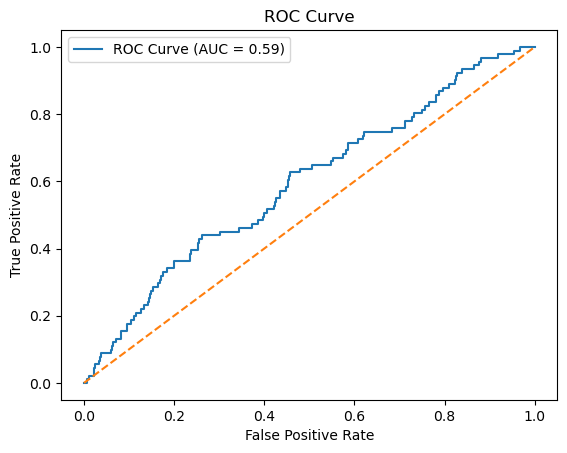

In [20]:
y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()